## ANN FOR XOR

In [1]:
#create xor dataset

import numpy as np
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])

print(X)
print(y)

[[0 0]
 [0 1]
 [1 0]
 [1 1]]
[[0]
 [1]
 [1]
 [0]]


In [2]:
#split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25, random_state=42)

In [3]:
#building ann

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(4, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
#train model

model.fit(X_train, y_train, epochs=200, verbose=0)

In [5]:
#predictions

pred=model.predict(X_test)
pred=(pred>0.5).astype(int)

print("pred:", pred)
print("actual", y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
pred: [[1]]
actual [[1]]


In [6]:
from sklearn.metrics import accuracy_score

print("accuracy:", accuracy_score(y_test, pred))

accuracy: 1.0


## XOR USING LOGREG

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_train = y_train.ravel()
y_test = y_test.ravel()

lr = LogisticRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, pred_lr))

LR Accuracy: 0.0


In [16]:
from sklearn.linear_model import LogisticRegression
y_train = y_train.ravel()
y_test = y_test.ravel()
lr = LogisticRegression().fit(X, y)
print(lr.predict(X))

[0 0 0 0]


C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier().fit(X, y)
print(dt.predict(X))

[0 1 1 0]


In [19]:
from sklearn.svm import SVC
svm_rbf = SVC(kernel='rbf').fit(X, y)
print(svm_rbf.predict(X))

[0 1 1 0]


C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## ACTIVATION FUNCTION PLOTS

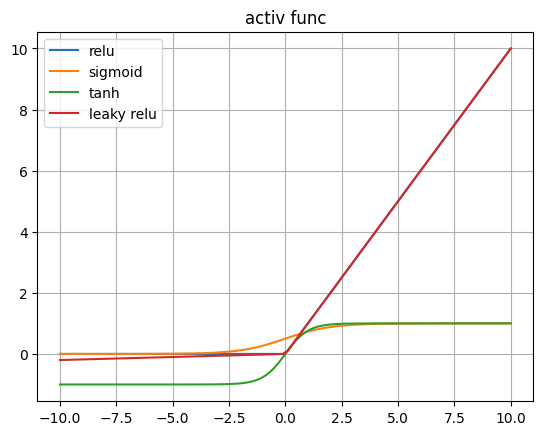

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-10,10,100)

relu=np.maximum(0,x)
sigmoid=1/(1+np.exp(-x))
tanh=np.tanh(x)
leakyrelu=np.maximum(0.02*x, x)

plt.plot(x, relu, label="relu")
plt.plot(x, sigmoid, label="sigmoid")
plt.plot(x, tanh, label="tanh")
plt.plot(x, leakyrelu, label="leaky relu")
plt.legend()
plt.grid()
plt.title("activ func")
plt.show()